In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Dataset Shape :", X.shape)

print("\nFirst Five Rows\n")

print(X.head())

print("\nTarget Classes")

print(data.target_names)

Dataset Shape : (569, 30)

First Five Rows

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  wo

In [3]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Samples :", len(X_train))

print("Testing Samples :", len(X_test))


Training Samples : 455
Testing Samples : 114


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed Successfully.")


Feature Scaling Completed Successfully.


In [5]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model Trained Successfully")

Model Trained Successfully


In [6]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix\n")

print(cm)


Confusion Matrix

[[41  1]
 [ 1 71]]


In [7]:
print("\nClassification Report\n")

print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [8]:
accuracy = model.score(X_test_scaled, y_test)

print("\nAccuracy :", round(accuracy,4))


Accuracy : 0.9825


In [9]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print("\nPerformance Metrics")

print("Precision :", round(report["weighted avg"]["precision"],4))

print("Recall    :", round(report["weighted avg"]["recall"],4))

print("F1 Score  :", round(report["weighted avg"]["f1-score"],4))


Performance Metrics
Precision : 0.9825
Recall    : 0.9825
F1 Score  : 0.9825


In [10]:
print("\nInterpretation")

print("- Precision measures how many predicted positives are actually correct.")

print("- Recall measures how many actual positives are detected.")

print("- F1 Score balances Precision and Recall.")

print("- Accuracy alone is not enough for imbalanced datasets.")


Interpretation
- Precision measures how many predicted positives are actually correct.
- Recall measures how many actual positives are detected.
- F1 Score balances Precision and Recall.
- Accuracy alone is not enough for imbalanced datasets.


AUC Score : 0.9954


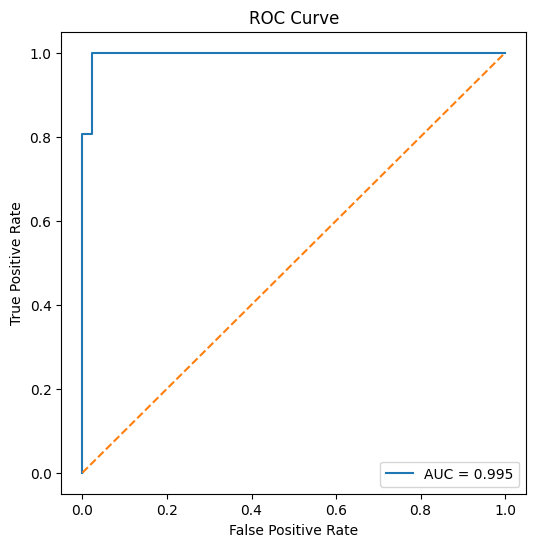

In [11]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC Score :", round(auc, 4))

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [12]:
balanced_model = LogisticRegression(

    class_weight="balanced",

    max_iter=1000

)

balanced_model.fit(

    X_train_scaled,

    y_train

)

balanced_prediction = balanced_model.predict(

    X_test_scaled

)

print("\nBalanced Logistic Regression\n")

print(classification_report(

    y_test,

    balanced_prediction

))


Balanced Logistic Regression

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [13]:
tree = DecisionTreeClassifier(

    random_state=42

)

tree.fit(

    X_train,

    y_train

)

tree_prediction = tree.predict(

    X_test

)

print("\nDecision Tree Classification Report\n")

print(classification_report(

    y_test,

    tree_prediction

))


Decision Tree Classification Report

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [14]:
logistic_accuracy = model.score(

    X_test_scaled,

    y_test

)

tree_accuracy = tree.score(

    X_test,

    y_test

)

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Balanced Logistic Regression",

        "Decision Tree"

    ],

    "Accuracy":[

        logistic_accuracy,

        balanced_model.score(

            X_test_scaled,

            y_test

        ),

        tree_accuracy

    ]

})

print("\nModel Comparison\n")

print(comparison)


Model Comparison

                          Model  Accuracy
0           Logistic Regression  0.982456
1  Balanced Logistic Regression  0.956140
2                 Decision Tree  0.912281


In [15]:
import joblib

joblib.dump(

    model,

    "AI_ML_Task4_Best_Model.pkl"

)

print("\nBest Model Saved Successfully")


Best Model Saved Successfully
